In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# [셀 0] 패키지 설치
!pip install ultralytics -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 31.8 MB/s eta 0:00:00


In [ ]:
# [셀 1] import
from pathlib import Path
import os
import cv2
import json
import math
import unicodedata
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ultralytics import YOLO
from PIL import Image
from datetime import datetime

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
# [셀 2] 기본 경로 설정 + best.pt 모델 로드

BASE_DIR = Path("/content/drive/MyDrive/먼작귀")
SHELF_DIR = BASE_DIR / "shelf_detection"
RUNS_DIR = SHELF_DIR / "runs"

TARGET_RUN_NAME = "선반앞턱_yolov8_seg_v2_100_aug"

print("SHELF_DIR:", SHELF_DIR)
print("RUNS_DIR:", RUNS_DIR)
print("RUNS_DIR 존재 여부:", RUNS_DIR.exists())

if not RUNS_DIR.exists():
    raise FileNotFoundError(f"RUNS_DIR를 찾지 못했습니다: {RUNS_DIR}")

target_norm = unicodedata.normalize("NFC", TARGET_RUN_NAME)
matched_dirs = []

for p in RUNS_DIR.iterdir():
    if not p.is_dir():
        continue
    name_norm = unicodedata.normalize("NFC", p.name)
    if name_norm == target_norm:
        matched_dirs.append(p)

print("매칭된 run 폴더 개수:", len(matched_dirs))

if len(matched_dirs) == 0:
    print("현재 runs 폴더 목록:")
    for p in RUNS_DIR.iterdir():
        if p.is_dir():
            print("-", unicodedata.normalize("NFC", p.name))
    raise FileNotFoundError(f"{TARGET_RUN_NAME} 폴더를 찾지 못했습니다.")

RUN_DIR = matched_dirs[0]
BEST_MODEL_PATH = RUN_DIR / "weights" / "best.pt"

print("RUN_DIR:", RUN_DIR)
print("BEST_MODEL_PATH:", BEST_MODEL_PATH)
print("best.pt 존재 여부:", BEST_MODEL_PATH.exists())

if not BEST_MODEL_PATH.exists():
    raise FileNotFoundError(f"best.pt를 찾지 못했습니다: {BEST_MODEL_PATH}")

model = YOLO(str(BEST_MODEL_PATH))
print("모델 로드 완료:", TARGET_RUN_NAME)

SHELF_DIR: /content/drive/MyDrive/먼작귀/shelf_detection
RUNS_DIR: /content/drive/MyDrive/먼작귀/shelf_detection/runs
RUNS_DIR 존재 여부: True
매칭된 run 폴더 개수: 1
RUN_DIR: /content/drive/MyDrive/먼작귀/shelf_detection/runs/선반앞턱_yolov8_seg_v2_100_aug
BEST_MODEL_PATH: /content/drive/MyDrive/먼작귀/shelf_detection/runs/선반앞턱_yolov8_seg_v2_100_aug/weights/best.pt
best.pt 존재 여부: True
모델 로드 완료: 선반앞턱_yolov8_seg_v2_100_aug


In [ ]:
# [셀 3] 결과 저장 폴더 설정

OUT_DIR = SHELF_DIR / "outputs" / "upper_line_postprocess_final_margin"
VIS_DIR = OUT_DIR / "visuals"
JSON_DIR = OUT_DIR / "json"
CSV_PATH = OUT_DIR / "upper_line_summary.csv"

VIS_DIR.mkdir(parents=True, exist_ok=True)
JSON_DIR.mkdir(parents=True, exist_ok=True)

print("OUT_DIR:", OUT_DIR)
print("VIS_DIR:", VIS_DIR)
print("JSON_DIR:", JSON_DIR)
print("CSV_PATH:", CSV_PATH)

OUT_DIR: /content/drive/MyDrive/먼작귀/shelf_detection/outputs/upper_line_postprocess_final_margin
VIS_DIR: /content/drive/MyDrive/먼작귀/shelf_detection/outputs/upper_line_postprocess_final_margin/visuals
JSON_DIR: /content/drive/MyDrive/먼작귀/shelf_detection/outputs/upper_line_postprocess_final_margin/json
CSV_PATH: /content/drive/MyDrive/먼작귀/shelf_detection/outputs/upper_line_postprocess_final_margin/upper_line_summary.csv


In [ ]:
# [셀 4] test 이미지 목록 불러오기

TEST_IMAGE_DIR = SHELF_DIR / "dataset" / "shelf_lip_yolo_seg" / "images" / "test"

print("TEST_IMAGE_DIR:", TEST_IMAGE_DIR)
print("TEST_IMAGE_DIR 존재 여부:", TEST_IMAGE_DIR.exists())

if not TEST_IMAGE_DIR.exists():
    raise FileNotFoundError(f"TEST_IMAGE_DIR를 찾지 못했습니다: {TEST_IMAGE_DIR}")

def list_image_paths(image_dir):
    exts = [".jpg", ".jpeg", ".png", ".bmp", ".webp", ".JPG", ".JPEG", ".PNG"]
    paths = []
    for ext in exts:
        paths.extend(list(image_dir.glob(f"*{ext}")))
    return sorted(set(paths))

image_paths = list_image_paths(TEST_IMAGE_DIR)

print("test 이미지 개수:", len(image_paths))
for i, p in enumerate(image_paths):
    print(i, p.name)

TEST_IMAGE_DIR: /content/drive/MyDrive/먼작귀/shelf_detection/dataset/shelf_lip_yolo_seg/images/test
TEST_IMAGE_DIR 존재 여부: True
test 이미지 개수: 13
0 IMG_8235.jpg
1 PhotoshopExtension_Image_12.jpeg
2 PhotoshopExtension_Image_21.jpeg
3 PhotoshopExtension_Image_22.jpeg
4 PhotoshopExtension_Image_26.jpeg
5 PhotoshopExtension_Image_54.jpeg
6 PhotoshopExtension_Image_6.jpeg
7 PhotoshopExtension_image0516_1.jpeg
8 PhotoshopExtension_images_11.jpeg
9 PhotoshopExtension_images_16.jpeg
10 PhotoshopExtension_images_4.jpeg
11 synthetic_s3_002.png
12 synthetic_s3_003.png


In [ ]:
# [셀 5] 예측/후처리 파라미터 설정

# =========================
# 예측 설정
# =========================
IMGSZ = 960
CONF_THRES = 0.12
IOU_THRES = 0.50

# =========================
# 윗선 후보 필터링 설정
# =========================
MIN_CANDIDATE_WIDTH_RATIO = 0.06
MIN_FINAL_WIDTH_RATIO = 0.12
MIN_AREA_RATIO = 0.00004

# 실제 사진/측면 이미지에서는 사선이 있을 수 있어서 넉넉하게 둠
MAX_ABS_ANGLE = 22

X_BIN = 6
SMOOTH_WINDOW = 9

# 같은 선반 라인의 조각 병합 기준
MERGE_Y_THRESH = 25
MERGE_SLOPE_THRESH = 0.25


# =========================
# target shelf group 선택 설정
# =========================
# raw_lines → merged_lines 이후,
# 전체 선 중에서 대상 매대에 해당하는 선반 그룹만 고르는 단계
USE_TARGET_GROUP_SELECTION = True

# 비슷한 기울기의 선끼리 같은 그룹으로 묶는 기준
TARGET_GROUP_ANGLE_THRESH = 7.0

# 너무 짧은 선은 target group 점수에서 불리하게 봄
TARGET_GROUP_MIN_WIDTH_RATIO = 0.18

# target group으로 인정할 최소 선 개수
TARGET_GROUP_MIN_LINES = 2

# 이미지 중앙부를 어느 정도 포함하는 그룹을 선호
TARGET_GROUP_CENTER_WEIGHT = 0.8

# 선 개수, 폭, y방향 span을 얼마나 중요하게 볼지
TARGET_GROUP_COUNT_WEIGHT = 3.0
TARGET_GROUP_WIDTH_WEIGHT = 2.0
TARGET_GROUP_XCOVER_WEIGHT = 2.0
TARGET_GROUP_YSPAN_WEIGHT = 1.0

# =========================
# 최종 중복선 제거 설정
# =========================
# 지금은 후보를 최대한 살리는 목적이므로 기본은 끔
USE_CLOSE_SUPPRESSION = False
MIN_VERTICAL_GAP = 80
UPPER_EDGE_WIDTH_KEEP_RATIO = 0.50

MAX_SHELF_LINES = 10

# =========================
# 선 연장 설정
# =========================
# 이미지 전체 폭으로 연장하면 배경 선반까지 가로질러서 이상해짐.
# 그래서 탐지된 구간 기준으로 좌우 margin만 확장.
EXTEND_LINE_TO_FULL_WIDTH = False
EXTEND_MARGIN_RATIO = 0.08

print("IMGSZ:", IMGSZ)
print("CONF_THRES:", CONF_THRES)
print("IOU_THRES:", IOU_THRES)
print("MIN_CANDIDATE_WIDTH_RATIO:", MIN_CANDIDATE_WIDTH_RATIO)
print("MIN_FINAL_WIDTH_RATIO:", MIN_FINAL_WIDTH_RATIO)
print("MAX_ABS_ANGLE:", MAX_ABS_ANGLE)
print("MERGE_Y_THRESH:", MERGE_Y_THRESH)
print("USE_TARGET_GROUP_SELECTION:", USE_TARGET_GROUP_SELECTION)
print("TARGET_GROUP_ANGLE_THRESH:", TARGET_GROUP_ANGLE_THRESH)
print("TARGET_GROUP_MIN_LINES:", TARGET_GROUP_MIN_LINES)
print("USE_CLOSE_SUPPRESSION:", USE_CLOSE_SUPPRESSION)
print("MAX_SHELF_LINES:", MAX_SHELF_LINES)
print("EXTEND_LINE_TO_FULL_WIDTH:", EXTEND_LINE_TO_FULL_WIDTH)
print("EXTEND_MARGIN_RATIO:", EXTEND_MARGIN_RATIO)

IMGSZ: 960
CONF_THRES: 0.12
IOU_THRES: 0.5
MIN_CANDIDATE_WIDTH_RATIO: 0.06
MIN_FINAL_WIDTH_RATIO: 0.12
MAX_ABS_ANGLE: 22
MERGE_Y_THRESH: 25
USE_TARGET_GROUP_SELECTION: True
TARGET_GROUP_ANGLE_THRESH: 7.0
TARGET_GROUP_MIN_LINES: 2
USE_CLOSE_SUPPRESSION: False
MAX_SHELF_LINES: 10
EXTEND_LINE_TO_FULL_WIDTH: False
EXTEND_MARGIN_RATIO: 0.08


In [ ]:
# [셀 6] 마스크에서 윗선 추출 함수

def polygon_to_mask(poly, h, w):
    """YOLO segmentation polygon을 binary mask로 변환"""
    mask = np.zeros((h, w), dtype=np.uint8)
    if poly is None or len(poly) < 3:
        return mask

    pts = np.array(poly, dtype=np.int32)
    pts[:, 0] = np.clip(pts[:, 0], 0, w - 1)
    pts[:, 1] = np.clip(pts[:, 1], 0, h - 1)
    cv2.fillPoly(mask, [pts], 1)
    return mask


def moving_median(values, window=9):
    """y값 smoothing용 median filter"""
    values = np.asarray(values, dtype=np.float32)
    if len(values) == 0:
        return values
    if window <= 1:
        return values
    if window % 2 == 0:
        window += 1

    pad = window // 2
    padded = np.pad(values, (pad, pad), mode="edge")
    smoothed = []
    for i in range(len(values)):
        smoothed.append(np.median(padded[i:i + window]))
    return np.array(smoothed, dtype=np.float32)


def robust_fit_line(points, max_iter=5, min_points=8):
    """point들로 y = ax + b 직선을 robust fitting"""
    points = np.asarray(points, dtype=np.float32)
    if len(points) < min_points:
        return None

    fit_points = points.copy()

    for _ in range(max_iter):
        if len(fit_points) < min_points:
            break

        x = fit_points[:, 0]
        y = fit_points[:, 1]

        try:
            a, b = np.polyfit(x, y, 1)
        except Exception:
            return None

        pred = a * x + b
        residual = np.abs(y - pred)
        threshold = max(6, np.percentile(residual, 80))
        keep = residual <= threshold

        if keep.sum() < min_points:
            break
        if keep.sum() == len(fit_points):
            break

        fit_points = fit_points[keep]

    if len(fit_points) < min_points:
        return None

    x = fit_points[:, 0]
    y = fit_points[:, 1]

    try:
        a, b = np.polyfit(x, y, 1)
    except Exception:
        return None

    return float(a), float(b), fit_points


# def extract_upper_line_from_mask(
#     mask,
#     conf=1.0,
#     min_width_ratio=0.06,
#     min_area_ratio=0.00004,
#     max_abs_angle=22,
#     x_bin=6,
#     smooth_window=9
# ):
#     """mask 전체 중심선이 아니라 mask의 윗변을 따라가는 선 추출"""
#     h, w = mask.shape[:2]
#     ys, xs = np.where(mask > 0)

#     ## 추가한거
#     LOWER_BAND_START = 0.55
#     LOWER_BAND_END = 0.95
#     LARGE_MASK_HEIGHT_RATIO = 0.15

#     if len(xs) == 0:
#         return None

#     area = len(xs)
#     area_ratio = area / (h * w)
#     if area_ratio < min_area_ratio:
#         return None

#     x_min = int(xs.min())
#     x_max = int(xs.max())
#     width = x_max - x_min
#     width_ratio = width / w

#     if width_ratio < min_width_ratio:
#         return None

#     upper_points = []

#     for x0 in range(x_min, x_max + 1, x_bin):
#         x1 = x0 + x_bin
#         idx = (xs >= x0) & (xs < x1)
#         if idx.sum() == 0:
#             continue

#         x_mid = (x0 + x1) / 2
#         y_top = np.percentile(ys[idx], 5)
#         upper_points.append([x_mid, y_top])

#     if len(upper_points) < 8:
#         return None

#     upper_points = np.array(upper_points, dtype=np.float32)
#     upper_points[:, 1] = moving_median(upper_points[:, 1], window=smooth_window)

#     fit_result = robust_fit_line(upper_points)
#     if fit_result is None:
#         return None

#     a, b, fit_points = fit_result
#     angle = math.degrees(math.atan(a))

#     if abs(angle) > max_abs_angle:
#         return None

#     x1 = int(np.min(fit_points[:, 0]))
#     x2 = int(np.max(fit_points[:, 0]))
#     y1 = int(a * x1 + b)
#     y2 = int(a * x2 + b)

#     x1 = int(np.clip(x1, 0, w - 1))
#     x2 = int(np.clip(x2, 0, w - 1))
#     y1 = int(np.clip(y1, 0, h - 1))
#     y2 = int(np.clip(y2, 0, h - 1))

#     line_length = math.sqrt((x2 - x1) ** 2 + (y2 - y1) ** 2)
#     line_width_ratio = abs(x2 - x1) / w

#     return {
#         "x1": x1,
#         "y1": y1,
#         "x2": x2,
#         "y2": y2,
#         "y_mid": float((y1 + y2) / 2),
#         "slope": float(a),
#         "intercept": float(b),
#         "angle": float(angle),
#         "conf": float(conf),
#         "max_conf": float(conf),
#         "line_length": float(line_length),
#         "width_ratio": float(line_width_ratio),
#         "source_count": 1,
#         "_points": fit_points.tolist(),
#     }
def extract_upper_line_from_mask(
    mask,
    conf=1.0,
    min_width_ratio=0.06,
    min_area_ratio=0.00004,
    max_abs_angle=22,
    x_bin=6,
    smooth_window=9,
    # box_xyxy=None,   # 추가
):
    """
    mask 전체 중심선이 아니라 mask의 윗변을 따라가는 선 추출.
    단, mask box가 너무 큰 경우에는 전체 mask를 쓰지 않고
    box의 하단 band 영역에서 선을 추출한다.
    """
    h, w = mask.shape[:2]
    ys, xs = np.where(mask > 0)

    if len(xs) == 0:
        return None

    # -----------------------------
    # 추가: 큰 mask는 하단 band만 사용
    # -----------------------------
    # LOWER_BAND_START = 0.55
    # LOWER_BAND_END = 0.95
    # LARGE_MASK_HEIGHT_RATIO = 0.15

    # used_band = "full"

    # if box_xyxy is not None:
    #     bx1, by1, bx2, by2 = box_xyxy
    #     box_h = by2 - by1
    #     box_h_ratio = box_h / h

    #     if box_h_ratio > LARGE_MASK_HEIGHT_RATIO:
    #         band_y1 = by1 + box_h * LOWER_BAND_START
    #         band_y2 = by1 + box_h * LOWER_BAND_END

    #         keep = (ys >= band_y1) & (ys <= band_y2)
    #         xs = xs[keep]
    #         ys = ys[keep]

    #         used_band = "lower"

    #         if len(xs) < 30:
    #             return None
    # -----------------------------

    area = len(xs)
    area_ratio = area / (h * w)
    if area_ratio < min_area_ratio:
        return None

    x_min = int(xs.min())
    x_max = int(xs.max())
    width = x_max - x_min
    width_ratio = width / w

    if width_ratio < min_width_ratio:
        return None

    upper_points = []

    for x0 in range(x_min, x_max + 1, x_bin):
        x1 = x0 + x_bin
        idx = (xs >= x0) & (xs < x1)
        if idx.sum() == 0:
            continue

        x_mid = (x0 + x1) / 2

        # 기존: 전체 mask에서는 윗변 사용
        # 큰 mask에서 lower band를 쓸 때는 band 안의 중앙값이 더 안정적
        # if used_band == "lower":
        #     y_top = np.percentile(ys[idx], 50)
        # else:
        y_top = np.percentile(ys[idx], 5)

        upper_points.append([x_mid, y_top])

    if len(upper_points) < 8:
        return None

    upper_points = np.array(upper_points, dtype=np.float32)
    upper_points[:, 1] = moving_median(upper_points[:, 1], window=smooth_window)

    fit_result = robust_fit_line(upper_points)
    if fit_result is None:
        return None

    a, b, fit_points = fit_result
    angle = math.degrees(math.atan(a))

    if abs(angle) > max_abs_angle:
        return None

    x1 = int(np.min(fit_points[:, 0]))
    x2 = int(np.max(fit_points[:, 0]))
    y1 = int(a * x1 + b)
    y2 = int(a * x2 + b)

    x1 = int(np.clip(x1, 0, w - 1))
    x2 = int(np.clip(x2, 0, w - 1))
    y1 = int(np.clip(y1, 0, h - 1))
    y2 = int(np.clip(y2, 0, h - 1))

    line_length = math.sqrt((x2 - x1) ** 2 + (y2 - y1) ** 2)
    line_width_ratio = abs(x2 - x1) / w

    return {
        "x1": x1,
        "y1": y1,
        "x2": x2,
        "y2": y2,
        "y_mid": float((y1 + y2) / 2),
        "slope": float(a),
        "intercept": float(b),
        "angle": float(angle),
        "conf": float(conf),
        "max_conf": float(conf),
        "line_length": float(line_length),
        "width_ratio": float(line_width_ratio),
        "source_count": 1,
        "_points": fit_points.tolist(),
        # "used_band": used_band,  # 디버그용
    }

In [ ]:
# [셀 7] 후처리 함수: 선 병합, target shelf group 선택, 선 연장, 최종 선 선택

def line_y_at(line, x):
    return line["slope"] * x + line["intercept"]


def get_line_x_center(line):
    x1 = line.get("detected_x1", line["x1"])
    x2 = line.get("detected_x2", line["x2"])
    return (x1 + x2) / 2


def get_line_x_span(line):
    x1 = line.get("detected_x1", line["x1"])
    x2 = line.get("detected_x2", line["x2"])
    return min(x1, x2), max(x1, x2)


def get_union_x_coverage(lines, image_w):
    """
    여러 선의 x구간 union coverage 계산.
    배경의 짧은 선반보다, 대상 매대처럼 넓게 퍼진 그룹을 선호하기 위함.
    """
    intervals = []

    for line in lines:
        x1, x2 = get_line_x_span(line)
        x1 = max(0, min(int(x1), image_w - 1))
        x2 = max(0, min(int(x2), image_w - 1))

        if x2 > x1:
            intervals.append((x1, x2))

    if len(intervals) == 0:
        return 0.0

    intervals = sorted(intervals, key=lambda x: x[0])

    merged = []
    cur_s, cur_e = intervals[0]

    for s, e in intervals[1:]:
        if s <= cur_e:
            cur_e = max(cur_e, e)
        else:
            merged.append((cur_s, cur_e))
            cur_s, cur_e = s, e

    merged.append((cur_s, cur_e))

    total = sum(e - s for s, e in merged)

    return total / image_w


def extend_line_to_valid_image_range(line, image_w, image_h):
    """
    선을 이미지 전체 폭까지 연장하되,
    y가 이미지 밖으로 나가면 이미지 안에 들어오는 x 범위까지만 사용.
    EXTEND_LINE_TO_FULL_WIDTH=True일 때만 사용.
    """
    new_line = line.copy()

    a = float(new_line["slope"])
    b = float(new_line["intercept"])

    new_line["detected_x1"] = int(new_line.get("detected_x1", new_line["x1"]))
    new_line["detected_y1"] = int(new_line.get("detected_y1", new_line["y1"]))
    new_line["detected_x2"] = int(new_line.get("detected_x2", new_line["x2"]))
    new_line["detected_y2"] = int(new_line.get("detected_y2", new_line["y2"]))

    x_left = 0
    x_right = image_w - 1

    if abs(a) > 1e-6:
        x_at_y0 = (0 - b) / a
        x_at_yh = ((image_h - 1) - b) / a

        valid_x_min = min(x_at_y0, x_at_yh)
        valid_x_max = max(x_at_y0, x_at_yh)

        x_left = max(0, int(math.ceil(valid_x_min)))
        x_right = min(image_w - 1, int(math.floor(valid_x_max)))

        if x_left >= x_right:
            x_left = int(new_line["detected_x1"])
            x_right = int(new_line["detected_x2"])

    y_left = int(a * x_left + b)
    y_right = int(a * x_right + b)

    y_left = int(np.clip(y_left, 0, image_h - 1))
    y_right = int(np.clip(y_right, 0, image_h - 1))

    new_line["x1"] = int(x_left)
    new_line["y1"] = int(y_left)
    new_line["x2"] = int(x_right)
    new_line["y2"] = int(y_right)
    new_line["y_mid"] = float((y_left + y_right) / 2)
    new_line["line_length"] = float(
        math.sqrt((x_right - x_left) ** 2 + (y_right - y_left) ** 2)
    )
    new_line["width_ratio"] = float(abs(x_right - x_left) / image_w)

    return new_line


def extend_line_with_detected_margin(line, image_w, image_h, margin_ratio=0.08):
    """
    이미지 전체 폭까지 연장하지 않고,
    원래 탐지된 구간 기준으로 좌우 margin만 확장한다.

    측면 이미지/실제 사진에서 배경 선반까지 선이 길게 뻗는 문제를 줄이기 위한 방식.
    """
    new_line = line.copy()

    a = float(new_line["slope"])
    b = float(new_line["intercept"])

    detected_x1 = int(new_line.get("detected_x1", new_line["x1"]))
    detected_x2 = int(new_line.get("detected_x2", new_line["x2"]))

    new_line["detected_x1"] = int(new_line.get("detected_x1", new_line["x1"]))
    new_line["detected_y1"] = int(new_line.get("detected_y1", new_line["y1"]))
    new_line["detected_x2"] = int(new_line.get("detected_x2", new_line["x2"]))
    new_line["detected_y2"] = int(new_line.get("detected_y2", new_line["y2"]))

    if detected_x1 > detected_x2:
        detected_x1, detected_x2 = detected_x2, detected_x1

    margin = int(image_w * margin_ratio)

    x1 = max(0, detected_x1 - margin)
    x2 = min(image_w - 1, detected_x2 + margin)

    y1 = int(a * x1 + b)
    y2 = int(a * x2 + b)

    y1 = int(np.clip(y1, 0, image_h - 1))
    y2 = int(np.clip(y2, 0, image_h - 1))

    new_line["x1"] = int(x1)
    new_line["y1"] = int(y1)
    new_line["x2"] = int(x2)
    new_line["y2"] = int(y2)
    new_line["y_mid"] = float((y1 + y2) / 2)
    new_line["line_length"] = float(
        math.sqrt((x2 - x1) ** 2 + (y2 - y1) ** 2)
    )
    new_line["width_ratio"] = float(abs(x2 - x1) / image_w)

    return new_line


def refit_line_from_points(points, image_w, image_h):
    """
    여러 조각 line의 point를 합쳐 다시 하나의 직선으로 fitting
    """
    fit_result = robust_fit_line(points)

    if fit_result is None:
        return None

    a, b, fit_points = fit_result

    x1 = int(np.min(fit_points[:, 0]))
    x2 = int(np.max(fit_points[:, 0]))

    y1 = int(a * x1 + b)
    y2 = int(a * x2 + b)

    x1 = int(np.clip(x1, 0, image_w - 1))
    x2 = int(np.clip(x2, 0, image_w - 1))
    y1 = int(np.clip(y1, 0, image_h - 1))
    y2 = int(np.clip(y2, 0, image_h - 1))

    angle = math.degrees(math.atan(a))
    line_length = math.sqrt((x2 - x1) ** 2 + (y2 - y1) ** 2)
    width_ratio = abs(x2 - x1) / image_w

    return {
        "x1": x1,
        "y1": y1,
        "x2": x2,
        "y2": y2,
        "y_mid": float((y1 + y2) / 2),
        "slope": float(a),
        "intercept": float(b),
        "angle": float(angle),
        "line_length": float(line_length),
        "width_ratio": float(width_ratio),
        "_points": fit_points.tolist()
    }


def merge_duplicate_lines(
    lines,
    image_w,
    image_h,
    y_thresh=25,
    slope_thresh=0.25
):
    """
    같은 선반 row가 여러 조각으로 잡힌 경우 하나로 병합.
    단, y 차이가 큰 서로 다른 선반 라인은 병합하지 않음.
    """
    if len(lines) == 0:
        return []

    lines = sorted(lines, key=lambda x: x["y_mid"])
    groups = []

    for line in lines:
        placed = False

        for group in groups:
            ref = group[0]
            x_ref = image_w / 2

            y_line = line_y_at(line, x_ref)
            y_ref = line_y_at(ref, x_ref)

            y_diff = abs(y_line - y_ref)
            slope_diff = abs(line["slope"] - ref["slope"])

            if y_diff <= y_thresh and slope_diff <= slope_thresh:
                group.append(line)
                placed = True
                break

        if not placed:
            groups.append([line])

    merged = []

    for group in groups:
        all_points = []
        confs = []

        for line in group:
            all_points.extend(line["_points"])
            confs.append(line.get("conf", 1.0))

        all_points = np.asarray(all_points, dtype=np.float32)

        merged_line = refit_line_from_points(
            all_points,
            image_w=image_w,
            image_h=image_h
        )

        if merged_line is None:
            merged_line = sorted(
                group,
                key=lambda x: x.get("line_length", 0),
                reverse=True
            )[0]

        merged_line["conf"] = float(np.mean(confs))
        merged_line["max_conf"] = float(np.max(confs))
        merged_line["source_count"] = int(len(group))

        # detected 좌표가 없으면 현재 좌표를 detected로 저장
        merged_line["detected_x1"] = int(merged_line.get("detected_x1", merged_line["x1"]))
        merged_line["detected_y1"] = int(merged_line.get("detected_y1", merged_line["y1"]))
        merged_line["detected_x2"] = int(merged_line.get("detected_x2", merged_line["x2"]))
        merged_line["detected_y2"] = int(merged_line.get("detected_y2", merged_line["y2"]))

        merged.append(merged_line)

    return merged


def build_angle_groups(lines, angle_thresh=7.0):
    """
    merged_lines를 angle 기준으로 그룹화.
    비슷한 기울기의 선반선끼리 같은 후보 그룹으로 묶는다.
    """
    if len(lines) == 0:
        return []

    lines_sorted = sorted(lines, key=lambda x: x["angle"])

    groups = []

    for line in lines_sorted:
        placed = False

        for group in groups:
            group_angles = [g["angle"] for g in group]
            group_angle_median = float(np.median(group_angles))

            if abs(line["angle"] - group_angle_median) <= angle_thresh:
                group.append(line)
                placed = True
                break

        if not placed:
            groups.append([line])

    return groups


def score_target_group(group, image_w, image_h):
    """
    target shelf group 후보 점수 계산.

    점수 기준:
    - 선 개수가 많을수록 좋음
    - 선들이 일정 폭 이상 길수록 좋음
    - x방향으로 넓게 커버할수록 좋음
    - y방향으로 여러 단을 형성할수록 좋음
    - 이미지 중앙부와 가까울수록 약간 유리
    """
    if len(group) == 0:
        return -1e9

    widths = np.array([line.get("width_ratio", 0.0) for line in group], dtype=float)
    y_mids = np.array([line.get("y_mid", 0.0) for line in group], dtype=float)
    x_centers = np.array([get_line_x_center(line) / image_w for line in group], dtype=float)

    n_lines = len(group)
    median_width = float(np.median(widths)) if len(widths) > 0 else 0.0
    x_coverage = float(get_union_x_coverage(group, image_w))
    y_span = float((np.max(y_mids) - np.min(y_mids)) / image_h) if len(y_mids) > 1 else 0.0
    center_penalty = float(abs(np.mean(x_centers) - 0.5))

    # 너무 짧은 선이 많은 그룹은 감점
    short_ratio = float(np.mean(widths < TARGET_GROUP_MIN_WIDTH_RATIO)) if len(widths) > 0 else 1.0

    score = (
        TARGET_GROUP_COUNT_WEIGHT * n_lines
        + TARGET_GROUP_WIDTH_WEIGHT * median_width
        + TARGET_GROUP_XCOVER_WEIGHT * x_coverage
        + TARGET_GROUP_YSPAN_WEIGHT * y_span
        - TARGET_GROUP_CENTER_WEIGHT * center_penalty
        - 1.5 * short_ratio
    )

    return float(score)


def select_target_shelf_group(merged_lines, image_w, image_h, verbose=False):
    """
    merged_lines 중에서 대상 매대에 해당하는 선반 그룹만 선택.

    개선 버전:
    1. angle 기준으로 1차 그룹화
    2. 같은 angle 그룹 안에서 x 위치 기준으로 sub-grouping
    3. 각 subgroup 점수 계산
    4. 가장 점수가 높은 subgroup 선택

    이렇게 해야 왼쪽 뒤 선반처럼 기울기는 비슷하지만
    x 위치가 다른 배경 선반을 분리할 수 있음.
    """
    if not USE_TARGET_GROUP_SELECTION:
        return merged_lines

    if len(merged_lines) == 0:
        return []

    angle_groups = build_angle_groups(
        merged_lines,
        angle_thresh=TARGET_GROUP_ANGLE_THRESH
    )

    group_infos = []
    global_group_idx = 0

    for angle_group_idx, angle_group in enumerate(angle_groups):
        subgroups = split_group_by_x_position(
            angle_group,
            image_w=image_w,
            x_center_thresh_ratio=0.18
        )

        for subgroup_idx, subgroup in enumerate(subgroups):
            score = score_target_group(subgroup, image_w, image_h)

            angles = [line["angle"] for line in subgroup]
            y_mids = [line["y_mid"] for line in subgroup]
            widths = [line.get("width_ratio", 0.0) for line in subgroup]
            x_centers = [get_line_x_center(line) / image_w for line in subgroup]

            group_infos.append({
                "group_idx": global_group_idx,
                "angle_group_idx": angle_group_idx,
                "subgroup_idx": subgroup_idx,
                "group": subgroup,
                "score": score,
                "n_lines": len(subgroup),
                "angle_median": float(np.median(angles)),
                "y_min": float(np.min(y_mids)),
                "y_max": float(np.max(y_mids)),
                "median_width": float(np.median(widths)),
                "x_coverage": float(get_union_x_coverage(subgroup, image_w)),
                "x_center_mean": float(np.mean(x_centers)),
            })

            global_group_idx += 1

    if len(group_infos) == 0:
        return merged_lines

    # 최소 선 개수 조건 만족 그룹 우선
    valid_groups = [
        info for info in group_infos
        if info["n_lines"] >= TARGET_GROUP_MIN_LINES
    ]

    if len(valid_groups) == 0:
        valid_groups = group_infos

    best_info = max(valid_groups, key=lambda x: x["score"])

    selected = best_info["group"]
    selected = sorted(selected, key=lambda x: x["y_mid"])

    if verbose:
        print("\n[target_shelf_group 디버그]")
        for info in sorted(group_infos, key=lambda x: x["score"], reverse=True):
            print(
                f"group={info['group_idx']} | "
                f"angle_group={info['angle_group_idx']} | "
                f"subgroup={info['subgroup_idx']} | "
                f"score={info['score']:.3f} | "
                f"n={info['n_lines']} | "
                f"angle={info['angle_median']:.2f} | "
                f"x_center={info['x_center_mean']:.2f} | "
                f"y=({info['y_min']:.1f}, {info['y_max']:.1f}) | "
                f"median_width={info['median_width']:.3f} | "
                f"x_cov={info['x_coverage']:.3f}"
            )

        print("선택된 group:", best_info["group_idx"])

    return selected

def suppress_abnormally_close_lines(lines, image_w):
    """
    가까운 중복선 제거.
    지금은 USE_CLOSE_SUPPRESSION=False면 사용되지 않음.
    """
    if len(lines) <= 1:
        return lines

    x_ref = image_w / 2

    for line in lines:
        line["_y_ref"] = float(line_y_at(line, x_ref))

    lines = sorted(lines, key=lambda x: x["_y_ref"])

    keep = [True] * len(lines)

    for i in range(len(lines) - 1):
        if not keep[i]:
            continue

        y_gap = lines[i + 1]["_y_ref"] - lines[i]["_y_ref"]
        slope_diff = abs(lines[i + 1]["slope"] - lines[i]["slope"])

        if y_gap <= MIN_VERTICAL_GAP and slope_diff <= MERGE_SLOPE_THRESH:
            upper = lines[i]
            lower = lines[i + 1]

            upper_width = upper.get("width_ratio", 0)
            lower_width = lower.get("width_ratio", 0)
            best_width = max(upper_width, lower_width)

            if upper_width >= best_width * UPPER_EDGE_WIDTH_KEEP_RATIO:
                keep[i + 1] = False
            else:
                keep[i] = False

    selected = [line for line, k in zip(lines, keep) if k]

    for line in selected:
        line.pop("_y_ref", None)

    return selected


def select_final_shelf_lines(lines, image_w, image_h):
    """
    최종 선반 기준선 선택
    - 짧은 선 제거
    - score 계산
    - 필요 시 가까운 중복선 제거
    - 선 연장 방식 선택
    - 위에서 아래 순서로 shelf_index 부여
    """
    final_lines = []

    for line in lines:
        width_ratio = line.get("width_ratio", 0)

        if width_ratio < MIN_FINAL_WIDTH_RATIO:
            continue

        length_score = min(width_ratio, 1.0)
        conf_score = line.get("max_conf", line.get("conf", 1.0))

        line["score"] = float(0.75 * length_score + 0.25 * conf_score)

        final_lines.append(line)

    if USE_CLOSE_SUPPRESSION:
        final_lines = suppress_abnormally_close_lines(
            final_lines,
            image_w=image_w
        )

    final_lines = sorted(
        final_lines,
        key=lambda x: x["score"],
        reverse=True
    )

    final_lines = final_lines[:MAX_SHELF_LINES]
    final_lines = sorted(final_lines, key=lambda x: x["y_mid"])

    if EXTEND_LINE_TO_FULL_WIDTH:
        final_lines = [
            extend_line_to_valid_image_range(
                line,
                image_w=image_w,
                image_h=image_h
            )
            for line in final_lines
        ]
    else:
        final_lines = [
            extend_line_with_detected_margin(
                line,
                image_w=image_w,
                image_h=image_h,
                margin_ratio=EXTEND_MARGIN_RATIO
            )
            for line in final_lines
        ]

    final_lines = sorted(final_lines, key=lambda x: x["y_mid"])

    for idx, line in enumerate(final_lines, start=1):
        line["shelf_index"] = idx

    return final_lines


def line_to_jsonable(line):
    """
    json 저장 가능한 형태로 변환
    """
    return {
        "shelf_index": int(line.get("shelf_index", -1)),
        "x1": int(line["x1"]),
        "y1": int(line["y1"]),
        "x2": int(line["x2"]),
        "y2": int(line["y2"]),
        "y_mid": float(line["y_mid"]),
        "slope": float(line["slope"]),
        "intercept": float(line["intercept"]),
        "angle": float(line["angle"]),
        "conf": float(line.get("conf", 0.0)),
        "max_conf": float(line.get("max_conf", line.get("conf", 0.0))),
        "line_length": float(line.get("line_length", 0.0)),
        "width_ratio": float(line.get("width_ratio", 0.0)),
        "score": float(line.get("score", 0.0)),
        "source_count": int(line.get("source_count", 1)),
        "detected_x1": int(line.get("detected_x1", line["x1"])),
        "detected_y1": int(line.get("detected_y1", line["y1"])),
        "detected_x2": int(line.get("detected_x2", line["x2"])),
        "detected_y2": int(line.get("detected_y2", line["y2"])),
        "target_group_selected": bool(line.get("target_group_selected", False)),
    }

def split_group_by_x_position(group, image_w, x_center_thresh_ratio=0.18):
    """
    angle이 비슷한 그룹 안에서,
    x 위치가 비슷한 선들끼리 다시 sub-grouping.

    목적:
    - 왼쪽 뒤 배경 선반과
    - 가운데 대상 매대가
    기울기는 비슷해도 x 위치가 다르면 분리하기 위함.
    """
    if len(group) == 0:
        return []

    x_center_thresh = image_w * x_center_thresh_ratio

    group_sorted = sorted(group, key=lambda line: get_line_x_center(line))

    subgroups = []

    for line in group_sorted:
        placed = False
        line_center = get_line_x_center(line)

        for subgroup in subgroups:
            centers = [get_line_x_center(g) for g in subgroup]
            subgroup_center = float(np.median(centers))

            if abs(line_center - subgroup_center) <= x_center_thresh:
                subgroup.append(line)
                placed = True
                break

        if not placed:
            subgroups.append([line])

    return subgroups

In [ ]:
def recover_lines_by_gap_anomaly(
    final_lines,
    candidate_lines,
    image_height,
    gap_ratio_thresh=1.45,
    min_gap_height_ratio=0.18,
    y_margin_ratio=0.18,
    duplicate_y_thresh=45
):
    """
    선반 개수를 고정하지 않고,
    final_lines 사이의 비정상적으로 큰 y gap 안에서만
    누락 후보 line을 복구하는 함수.
    """

    if len(final_lines) < 2:
        return final_lines

    final_lines = sorted(final_lines, key=lambda x: x["y_mid"])

    # 1. 인접 선 사이 gap 계산
    gaps = []
    for i in range(len(final_lines) - 1):
        gap = final_lines[i + 1]["y_mid"] - final_lines[i]["y_mid"]
        gaps.append(gap)

    if len(gaps) == 0:
        return final_lines

    median_gap = np.median(gaps)

    recovered_lines = list(final_lines)

    # 2. 비정상적으로 큰 gap만 확인
    for i, gap in enumerate(gaps):
        upper = final_lines[i]
        lower = final_lines[i + 1]

        is_large_gap = gap > median_gap * gap_ratio_thresh
        is_physically_large = gap > image_height * min_gap_height_ratio

        if not (is_large_gap and is_physically_large):
            continue

        y_min = upper["y_mid"]
        y_max = lower["y_mid"]

        # gap 중앙 근처
        expected_y = (y_min + y_max) / 2
        y_margin = gap * y_margin_ratio

        # 3. gap 내부 후보만 탐색
        near_candidates = []
        for cand in candidate_lines:
            cy = cand["y_mid"]

            # 이미 선택된 선과 너무 가까우면 제외
            if any(abs(cy - line["y_mid"]) < duplicate_y_thresh for line in recovered_lines):
                continue

            # 큰 gap 내부에 있고, 중앙 근처면 후보
            if y_min + duplicate_y_thresh < cy < y_max - duplicate_y_thresh:
                if abs(cy - expected_y) <= max(y_margin, 70):
                    near_candidates.append(cand)

        if len(near_candidates) == 0:
            continue

        # 4. 후보 중 가장 그럴듯한 선 선택
        best = max(
            near_candidates,
            key=lambda x: (
                x.get("width_ratio", 0) * 0.6
                + x.get("conf", 0) * 0.3
                - abs(x["y_mid"] - expected_y) / image_height * 0.1
            )
        )

        best = dict(best)
        best["recovered"] = True
        best["recovery_reason"] = "large_gap_candidate"
        recovered_lines.append(best)

    # 5. 다시 y 기준 정렬 후 shelf_index 재부여
    recovered_lines = sorted(recovered_lines, key=lambda x: x["y_mid"])

    for idx, line in enumerate(recovered_lines, start=1):
        line["shelf_index"] = idx

    return recovered_lines

In [ ]:
# [셀 8] 이미지 예측 함수 + 결과 시각화 함수

def read_image_bgr(image_path):
    """
    한글 경로 / 아이폰 사진 대응용 이미지 로더.
    cv2.imread 대신 PIL로 읽고 BGR로 변환한다.
    """
    image_path = Path(image_path)

    if not image_path.exists():
        raise FileNotFoundError(f"이미지 파일이 존재하지 않습니다: {image_path}")

    try:
        pil_img = Image.open(image_path).convert("RGB")
        img_rgb = np.array(pil_img)
        img_bgr = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR)
        return img_bgr
    except Exception as e:
        raise FileNotFoundError(f"이미지를 읽지 못했습니다: {image_path}\n원인: {e}")

# 추가한거
def filter_front_large_shelf_candidates(lines, image_w, image_h):
    """
    왼쪽/오른쪽 배경 선반, 이미지 상단 배경선을 제외하고
    앞쪽 큰 매대에 해당할 가능성이 높은 line만 남긴다.
    """
    filtered = []

    for line in lines:
        x1 = line["x1"]
        x2 = line["x2"]
        y_mid = line["y_mid"]

        x_min = min(x1, x2)
        x_max = max(x1, x2)

        width_ratio = (x_max - x_min) / image_w
        x_center_ratio = ((x_min + x_max) / 2) / image_w
        y_ratio = y_mid / image_h

        # 1) 너무 짧은 선 제거
        # 왼쪽 배경 선반은 width_ratio가 대체로 작음
        if width_ratio < 0.25:
            continue

        # 2) 너무 왼쪽에만 있는 선 제거
        # 뒤쪽 과자 선반은 x_center가 왼쪽으로 쏠림
        if x_center_ratio < 0.25:
            continue

        # 3) 너무 오른쪽 끝에만 있는 선 제거
        if x_center_ratio > 0.90:
            continue

        # 4) 이미지 너무 위쪽 선 제거
        # 냉장고/배경 상단선 방지
        if y_ratio < 0.18:
            continue

        filtered.append(line)

    return filtered



def synthesize_missing_lines_by_gap(
    final_lines,
    image_w,
    image_h,
    gap_ratio_thresh=1.35,
    min_gap_height_ratio=0.10,
):
    """
    YOLO mask ??? ?? ??? recover_lines_by_gap_anomaly()? ???? ??? ??,
    ?? ?? ??? ? y gap? ?? ?/?? ?? ??? synthetic line? ????.

    ??: ?? ???? ??? ?? ?? geometry ??? ?????.
    """
    if len(final_lines) < 2:
        return final_lines

    lines = sorted([dict(line) for line in final_lines], key=lambda x: x["y_mid"])
    gaps = [lines[i + 1]["y_mid"] - lines[i]["y_mid"] for i in range(len(lines) - 1)]
    positive_gaps = [g for g in gaps if g > 0]

    if not positive_gaps:
        return lines

    reference_gap = min(positive_gaps)
    min_large_gap = max(reference_gap * gap_ratio_thresh, image_h * min_gap_height_ratio)
    synthesized = []
    x_ref = image_w / 2

    for i, gap in enumerate(gaps):
        upper = lines[i]
        lower = lines[i + 1]
        synthesized.append(upper)

        if gap < min_large_gap:
            continue

        # ?? ???? ??? gap? ??? ???? ??? ? gap? 1?? ???.
        y_ref = (upper["y_mid"] + lower["y_mid"]) / 2
        slope = float((upper["slope"] + lower["slope"]) / 2)
        intercept = float(y_ref - slope * x_ref)

        ux1 = upper.get("detected_x1", upper["x1"])
        ux2 = upper.get("detected_x2", upper["x2"])
        lx1 = lower.get("detected_x1", lower["x1"])
        lx2 = lower.get("detected_x2", lower["x2"])

        # v8: ?? ???? ?? ?/? ?? ???? ???? ??? ? ??.
        # ?/?? ?? ?? span? ??? union span? ??, ?? margin? ?? ?? ??? ?? ??.
        neighbor_xs = [ux1, ux2, lx1, lx2]
        x_margin = int(image_w * 0.015)
        x1 = int(np.clip(min(neighbor_xs) - x_margin, 0, image_w - 1))
        x2 = int(np.clip(max(neighbor_xs) + x_margin, 0, image_w - 1))
        if x1 > x2:
            x1, x2 = x2, x1

        y1 = int(np.clip(slope * x1 + intercept, 0, image_h - 1))
        y2 = int(np.clip(slope * x2 + intercept, 0, image_h - 1))
        angle = math.degrees(math.atan(slope))
        line_length = math.sqrt((x2 - x1) ** 2 + (y2 - y1) ** 2)

        synth_line = {
            "x1": x1,
            "y1": y1,
            "x2": x2,
            "y2": y2,
            "y_mid": float((y1 + y2) / 2),
            "slope": float(slope),
            "intercept": float(intercept),
            "angle": float(angle),
            "conf": 0.0,
            "max_conf": 0.0,
            "line_length": float(line_length),
            "width_ratio": float(abs(x2 - x1) / image_w),
            "score": 0.0,
            "source_count": 0,
            "detected_x1": x1,
            "detected_y1": y1,
            "detected_x2": x2,
            "detected_y2": y2,
            "target_group_selected": False,
            "synthesized": True,
            "synthesis_reason": "large_gap_interpolation",
        }
        synthesized.append(synth_line)

    synthesized.append(lines[-1])
    synthesized = sorted(synthesized, key=lambda x: x["y_mid"])

    for idx, line in enumerate(synthesized, start=1):
        line["shelf_index"] = idx

    return synthesized



def snap_synthesized_lines_to_strong_edge(lines, img_bgr, image_w, image_h):
    """
    v7: synthesized line? ???? ???? ?? fitting?? ???.
    ?? ?? edge? ???? ?? ??? ??? ????? ??? ?? ??,
    ?? ?? perspective? ?? slope? ???? line ??? ?/?? offset??? ?????.
    """
    if len(lines) == 0:
        return lines

    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    gray = cv2.GaussianBlur(gray, (5, 5), 0)
    grad_y = cv2.Sobel(gray, cv2.CV_32F, 0, 1, ksize=3)
    edge_strength = np.abs(grad_y)

    snapped_lines = []

    for line in lines:
        if not line.get("synthesized", False):
            snapped_lines.append(line)
            continue

        a = float(line["slope"])
        b = float(line["intercept"])
        x1 = int(min(line["x1"], line["x2"]))
        x2 = int(max(line["x1"], line["x2"]))

        if x2 - x1 < image_w * 0.15:
            snapped_lines.append(line)
            continue

        # ? ???? edge score? ??? ?? ??? ?? edge? ? ????.
        step = max(10, int(image_w / 120))
        xs = np.arange(x1, x2 + 1, step, dtype=np.int32)
        if len(xs) < 12:
            snapped_lines.append(line)
            continue

        # ???? ?? ??? ??? ?? ??? ???? ?? ? ?? ??,
        # slope? ???? offset? ???.
        offsets = np.arange(-70, 151, 3, dtype=np.int32)
        best_score = -1e9
        best_offset = 0

        for off in offsets:
            ys = np.round(a * xs + b + off).astype(np.int32)
            valid = (ys >= 2) & (ys < image_h - 2)
            if valid.sum() < len(xs) * 0.65:
                continue

            vxs = xs[valid]
            vys = ys[valid]
            samples = []
            coverage_hits = 0

            for x, y in zip(vxs, vys):
                xl = max(0, int(x) - 18)
                xr = min(image_w - 1, int(x) + 18)
                row_score = float(edge_strength[int(y), xl:xr + 1].mean())
                samples.append(row_score)
                if row_score > 18:
                    coverage_hits += 1

            if not samples:
                continue

            samples = np.asarray(samples, dtype=np.float32)
            mean_edge = float(np.mean(samples))
            p70_edge = float(np.percentile(samples, 70))
            continuity = coverage_hits / max(1, len(samples))

            # ?? ?? ??? offset? ??. ?, ??? ??? ?? ??.
            distance_penalty = abs(float(off)) / 150.0
            lower_bonus = max(0.0, float(off)) / 150.0 * 4.0

            score = 0.55 * mean_edge + 0.35 * p70_edge + 18.0 * continuity - 7.0 * distance_penalty + lower_bonus

            if score > best_score:
                best_score = score
                best_offset = int(off)

        # edge ??? ??? ?? ??? ??
        if best_score < 18:
            snapped_lines.append(line)
            continue

        new_b = b + best_offset
        new_line = dict(line)
        new_y1 = int(np.clip(a * x1 + new_b, 0, image_h - 1))
        new_y2 = int(np.clip(a * x2 + new_b, 0, image_h - 1))
        angle = math.degrees(math.atan(a))

        new_line.update({
            "x1": x1,
            "y1": new_y1,
            "x2": x2,
            "y2": new_y2,
            "detected_x1": x1,
            "detected_y1": new_y1,
            "detected_x2": x2,
            "detected_y2": new_y2,
            "y_mid": float((new_y1 + new_y2) / 2),
            "slope": float(a),
            "intercept": float(new_b),
            "angle": float(angle),
            "line_length": float(math.sqrt((x2 - x1) ** 2 + (new_y2 - new_y1) ** 2)),
            "width_ratio": float(abs(x2 - x1) / image_w),
            "snapped_to_edge": True,
            "snap_mode": "whole_line_offset",
            "snap_offset": int(best_offset),
            "snap_score": float(best_score),
        })
        snapped_lines.append(new_line)

    snapped_lines = sorted(snapped_lines, key=lambda x: x["y_mid"])
    for idx, line in enumerate(snapped_lines, start=1):
        line["shelf_index"] = idx

    return snapped_lines



def suppress_close_keep_upper_line(lines, image_w, image_h, y_thresh_ratio=0.035, slope_thresh=0.08):
    """
    v10 safe: Hough fallback? ?? ??, ?? ???? ??? ?? ???? ????.
    ?? ???/???? ? ? ?? ???? ?? ??? ???.
    """
    if len(lines) <= 1:
        return lines

    y_thresh = max(14, image_h * y_thresh_ratio)
    x_ref = image_w / 2
    items = []

    for line in lines:
        item = dict(line)
        item["_y_ref"] = float(line_y_at(item, x_ref))
        items.append(item)

    items = sorted(items, key=lambda x: x["_y_ref"])
    kept = []

    for line in items:
        duplicate_idx = None

        for idx, kept_line in enumerate(kept):
            y_gap = abs(line["_y_ref"] - kept_line["_y_ref"])
            slope_gap = abs(line["slope"] - kept_line["slope"])

            l1, r1 = sorted([line["x1"], line["x2"]])
            l2, r2 = sorted([kept_line["x1"], kept_line["x2"]])
            overlap = max(0, min(r1, r2) - max(l1, l2))
            min_width = max(1, min(r1 - l1, r2 - l2))
            overlap_ratio = overlap / min_width

            if y_gap <= y_thresh and slope_gap <= slope_thresh and overlap_ratio >= 0.45:
                duplicate_idx = idx
                break

        if duplicate_idx is None:
            kept.append(line)
        else:
            # ??? ??? ? ?? ???? y? ? ?? ???.
            if line["_y_ref"] < kept[duplicate_idx]["_y_ref"]:
                kept[duplicate_idx] = line

    kept = sorted(kept, key=lambda x: x["_y_ref"])
    for line in kept:
        line.pop("_y_ref", None)

    for idx, line in enumerate(kept, start=1):
        line["shelf_index"] = idx

    return kept



def extend_lines_to_common_front_span(lines, image_w, image_h):
    """
    ?? ??/?? ????? ?? ???? x ??? ? ???? ????.
    Hough?? ? ?? ???? ??, ?? ??? ?? ??? ?? front span? ????.
    """
    if len(lines) == 0:
        return lines

    valid_lines = [line for line in lines if line.get("width_ratio", 0) >= 0.20]
    if len(valid_lines) < 2:
        return lines

    xs = []
    for line in valid_lines:
        xs.extend([
            line.get("detected_x1", line["x1"]),
            line.get("detected_x2", line["x2"]),
            line["x1"],
            line["x2"],
        ])

    common_x1 = int(np.clip(np.percentile(xs, 5) - image_w * 0.01, 0, image_w - 1))
    common_x2 = int(np.clip(np.percentile(xs, 95) + image_w * 0.01, 0, image_w - 1))

    if common_x2 - common_x1 < image_w * 0.35:
        return lines

    extended = []
    for line in lines:
        cur_left = min(line["x1"], line["x2"])
        cur_right = max(line["x1"], line["x2"])

        # ?? ??/???? ?? ??? ??? ???? ??? ??? ????.
        x1 = min(cur_left, common_x1)
        x2 = max(cur_right, common_x2)
        x1 = int(np.clip(x1, 0, image_w - 1))
        x2 = int(np.clip(x2, 0, image_w - 1))

        new_line = dict(line)
        a = float(new_line["slope"])
        b = float(new_line["intercept"])
        y1 = int(np.clip(a * x1 + b, 0, image_h - 1))
        y2 = int(np.clip(a * x2 + b, 0, image_h - 1))

        new_line.update({
            "x1": x1,
            "y1": y1,
            "x2": x2,
            "y2": y2,
            "y_mid": float((y1 + y2) / 2),
            "line_length": float(math.sqrt((x2 - x1) ** 2 + (y2 - y1) ** 2)),
            "width_ratio": float(abs(x2 - x1) / image_w),
            "extended_to_common_front_span": True,
        })
        extended.append(new_line)

    extended = sorted(extended, key=lambda x: x["y_mid"])
    for idx, line in enumerate(extended, start=1):
        line["shelf_index"] = idx

    return extended


def predict_upper_lines_for_image(
    image_path,
    model,
    imgsz=960,
    conf_thres=0.12,
    iou_thres=0.50,
    min_width_ratio=0.06,
    min_area_ratio=0.00004,
    verbose_group=False,
):
    image_path = Path(image_path)

    img = read_image_bgr(image_path)
    h, w = img.shape[:2]

    result = model.predict(
        source=str(image_path),
        imgsz=imgsz,
        conf=conf_thres,
        iou=iou_thres,
        retina_masks=True,
        verbose=False
    )[0]

    raw_lines = []

    if result.masks is None:
        return [], result

    polys = result.masks.xy

    if result.boxes is not None and result.boxes.conf is not None:
        confs = result.boxes.conf.detach().cpu().numpy().tolist()
    else:
        confs = [1.0] * len(polys)

    # for poly, conf in zip(polys, confs):
    #     mask = polygon_to_mask(poly, h, w)

    #     line = extract_upper_line_from_mask(
    #         mask,
    #         conf=conf,
    #         min_width_ratio=min_width_ratio,
    #         min_area_ratio=min_area_ratio,
    #         max_abs_angle=MAX_ABS_ANGLE,
    #         x_bin=X_BIN,
    #         smooth_window=SMOOTH_WINDOW
    #     )

    #     if line is not None:
    #         raw_lines.append(line)

    # box 좌표도 같이 가져오기
    ## 추가한
    if result.boxes is not None and result.boxes.xyxy is not None:
        boxes_xyxy = result.boxes.xyxy.detach().cpu().numpy()
    else:
        boxes_xyxy = [None] * len(polys)

    for poly, conf, xyxy in zip(polys, confs, boxes_xyxy):
        mask = polygon_to_mask(poly, h, w)

        line = extract_upper_line_from_mask(
            mask,
            conf=conf,
            min_width_ratio=min_width_ratio,
            min_area_ratio=min_area_ratio,
            max_abs_angle=MAX_ABS_ANGLE,
            x_bin=X_BIN,
            smooth_window=SMOOTH_WINDOW,
            # box_xyxy=xyxy,   # 추가
        )

        if line is not None:
            raw_lines.append(line)

    # 잠깐 빼
    # merged_lines = merge_duplicate_lines(
    #     raw_lines,
    #     image_w=w,
    #     image_h=h,
    #     y_thresh=MERGE_Y_THRESH,
    #     slope_thresh=MERGE_SLOPE_THRESH
    # )

    # # 핵심 추가:
    # # merged_lines 전체에서 대상 매대에 해당하는 group만 선택
    # target_group_lines = select_target_shelf_group(
    #     merged_lines,
    #     image_w=w,
    #     image_h=h,
    #     verbose=verbose_group
    # )

    merged_lines = merge_duplicate_lines(
    raw_lines,
    image_w=w,
    image_h=h,
    y_thresh=MERGE_Y_THRESH,
    slope_thresh=MERGE_SLOPE_THRESH
)

    # 앞쪽 큰 매대 후보 안에서만 target group 선택
    # Existing filter_front_large_shelf_candidates() was defined but not used,
    # so long background lines near the top could win target-group selection.
    front_candidate_lines = filter_front_large_shelf_candidates(
        merged_lines,
        image_w=w,
        image_h=h
    )

    # Use the front-shelf filter only when it leaves enough candidates.
    group_input_lines = (
        front_candidate_lines
        if len(front_candidate_lines) >= TARGET_GROUP_MIN_LINES
        else merged_lines
    )

    if verbose_group:
        print("front_candidate_lines count:", len(front_candidate_lines))
        print("target group input line count:", len(group_input_lines))

    target_group_lines = select_target_shelf_group(
        group_input_lines,
        image_w=w,
        image_h=h,
        verbose=verbose_group
    )

    for line in target_group_lines:
        line["target_group_selected"] = True

    final_lines = select_final_shelf_lines(
        target_group_lines,
        image_w=w,
        image_h=h
    )

    # Recover a missing shelf lip inside an unusually large vertical gap.
    # This catches cases where target-group angle selection drops the 2nd shelf lip.
    recovery_candidates = front_candidate_lines if len(front_candidate_lines) > 0 else merged_lines
    final_lines = recover_lines_by_gap_anomaly(
        final_lines=final_lines,
        candidate_lines=recovery_candidates,
        image_height=img.shape[0],
        gap_ratio_thresh=1.18,
        min_gap_height_ratio=0.08,
        y_margin_ratio=0.38,
        duplicate_y_thresh=45
    )

    # Re-extend any recovered raw candidate so output coordinates stay consistent.
    final_lines = [
        extend_line_with_detected_margin(
            line,
            image_w=w,
            image_h=h,
            margin_ratio=EXTEND_MARGIN_RATIO
        )
        if line.get("recovered", False) and not EXTEND_LINE_TO_FULL_WIDTH
        else line
        for line in final_lines
    ]

    final_lines = sorted(final_lines, key=lambda x: x["y_mid"])
    for idx, line in enumerate(final_lines, start=1):
        line["shelf_index"] = idx

    # If the model produced no candidate at all for a missing shelf lip,
    # add one interpolated line in the unusually large gap.
    final_lines = synthesize_missing_lines_by_gap(
        final_lines,
        image_w=w,
        image_h=h,
        gap_ratio_thresh=1.28,
        min_gap_height_ratio=0.08
    )

    final_lines = snap_synthesized_lines_to_strong_edge(
        final_lines,
        img_bgr=img,
        image_w=w,
        image_h=h
    )

    # Hough fallback ??, ??? ?/? ???? ???? ????.
    final_lines = suppress_close_keep_upper_line(
        final_lines,
        image_w=w,
        image_h=h,
        y_thresh_ratio=0.035,
        slope_thresh=0.08
    )

    # ?? ??? ?? ?? span?? ??? ?? ?? ??? ?? ?? ???.
    final_lines = extend_lines_to_common_front_span(
        final_lines,
        image_w=w,
        image_h=h
    )

    return final_lines, result


def draw_upper_lines(image_path, lines, save_path=None):
    image_path = Path(image_path)

    img = read_image_bgr(image_path)
    vis = img.copy()

    for line in lines:
        x1, y1 = int(line["x1"]), int(line["y1"])
        x2, y2 = int(line["x2"]), int(line["y2"])
        shelf_index = line.get("shelf_index", "?")

        cv2.line(vis, (x1, y1), (x2, y2), (0, 255, 0), 4)

        cv2.circle(vis, (x1, y1), 5, (0, 0, 255), -1)
        cv2.circle(vis, (x2, y2), 5, (0, 0, 255), -1)

        label = f"Shelf {shelf_index}"

        text_x = max(5, x1)
        text_y = max(25, y1 - 8)

        cv2.putText(
            vis,
            label,
            (text_x, text_y),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.8,
            (0, 255, 0),
            2,
            cv2.LINE_AA
        )

    if save_path is not None:
        cv2.imwrite(str(save_path), vis)

    return vis

테스트 이미지: synthetic_s3_002.png
front_candidate_lines count: 3
target group input line count: 3

[target_shelf_group 디버그]
group=0 | angle_group=0 | subgroup=0 | score=11.699 | n=3 | angle=-16.78 | x_center=0.56 | y=(480.5, 1154.0) | median_width=0.547 | x_cov=0.606
선택된 group: 0
추출된 최종 윗선 개수: 4


,shelf_index,x1,y1,x2,y2,y_mid,angle,conf,width_ratio,detected_x1,detected_y1,detected_x2,detected_y2
0,1,409,628,1878,327,477.5,-11.577560,0.403594,0.717285,623,584,1631,377
1,2,409,866,1878,494,680.0,-14.206802,0.000000,0.717285,514,839,1695,540
2,3,381,1131,1878,679,905.0,-16.776380,0.600203,0.730957,544,1082,1665,744
3,4,409,1446,1948,876,1161.0,-20.319802,0.854180,0.751465,609,1372,1785,936


저장 완료: /content/drive/MyDrive/먼작귀/shelf_detection/outputs/upper_line_postprocess_final_margin/visuals/synthetic_s3_002_upper_lines.jpg


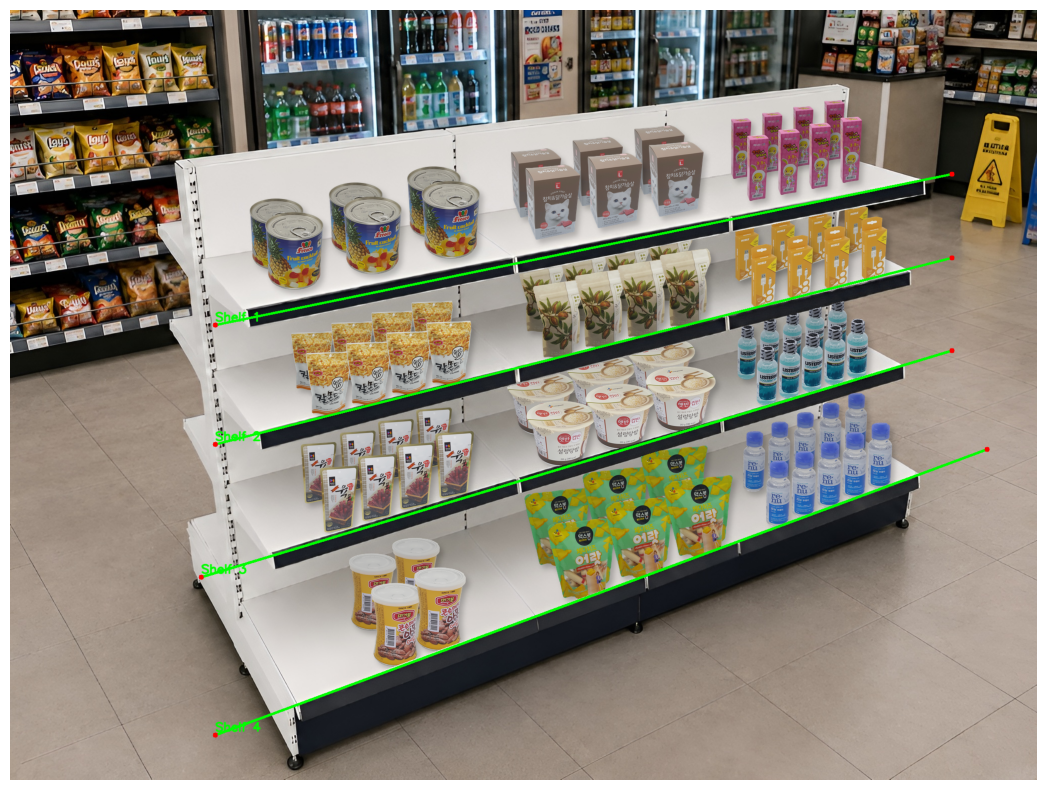

In [ ]:
# [셀 9] 샘플 이미지 1장 윗선 추출 결과 확인

SAMPLE_IDX = 11

sample_path = image_paths[SAMPLE_IDX]
print("테스트 이미지:", sample_path.name)

lines, result = predict_upper_lines_for_image(
    sample_path,
    model,
    imgsz=IMGSZ,
    conf_thres=CONF_THRES,
    iou_thres=IOU_THRES,
    min_width_ratio=MIN_CANDIDATE_WIDTH_RATIO,
    min_area_ratio=MIN_AREA_RATIO,
    verbose_group=True,   # 여기 True로 확인
)

print("추출된 최종 윗선 개수:", len(lines))

if len(lines) > 0:
    result_df = pd.DataFrame([line_to_jsonable(line) for line in lines])
    display(result_df[[
        "shelf_index",
        "x1", "y1", "x2", "y2",
        "y_mid",
        "angle",
        "conf",
        "width_ratio",
        "detected_x1", "detected_y1", "detected_x2", "detected_y2",
    ]])

save_path = VIS_DIR / f"{sample_path.stem}_upper_lines.jpg"
vis = draw_upper_lines(sample_path, lines, save_path=save_path)

print("저장 완료:", save_path)

plt.figure(figsize=(16, 10))
plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

In [ ]:
img_path = TEST_IMAGE_DIR / "synthetic_s3_002.png"

results = model.predict(
    source=str(img_path),
    imgsz=960,
    conf=0.12,
    iou=0.5,
    save=False,
    verbose=False
)

r = results[0]

print("boxes:", None if r.boxes is None else len(r.boxes))
print("masks:", None if r.masks is None else len(r.masks))

if r.boxes is not None:
    for i, box in enumerate(r.boxes):
        conf = float(box.conf[0])
        xyxy = box.xyxy[0].cpu().numpy()
        print(f"[{i}] conf={conf:.3f}, box={xyxy}")

boxes: 12
masks: 12
[0] conf=0.854, box=[     536.93      909.21      1787.6      1425.2]
[1] conf=0.786, box=[     343.08      689.15      1784.8      1141.5]
[2] conf=0.635, box=[          0      160.78      402.47      205.46]
[3] conf=0.549, box=[          0      18.097      419.56      44.936]
[4] conf=0.519, box=[     2.6626      595.61       352.1      682.86]
[5] conf=0.447, box=[      3.944      462.96      301.41      538.27]
[6] conf=0.414, box=[     346.71      518.59      1781.5      880.96]
[7] conf=0.404, box=[     314.07      347.97      1783.2      634.52]
[8] conf=0.242, box=[     1868.2      157.49      2047.3      197.88]
[9] conf=0.166, box=[     372.76      1108.1      594.57      1486.3]
[10] conf=0.153, box=[       1868      52.445      2046.3      88.474]
[11] conf=0.140, box=[     2.9897      318.95      319.21      372.56]


In [ ]:
for i, box in enumerate(r.boxes):
    conf = float(box.conf[0])
    x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()

    print(
        f"[MASK {i}] conf={conf:.3f} "
        f"box=({x1:.1f}, {y1:.1f}, {x2:.1f}, {y2:.1f}) "
        f"box_h={y2-y1:.1f}"
    )


[MASK 0] conf=0.854 box=(536.9, 909.2, 1787.6, 1425.2) box_h=516.0
[MASK 1] conf=0.786 box=(343.1, 689.2, 1784.8, 1141.5) box_h=452.3
[MASK 2] conf=0.635 box=(0.0, 160.8, 402.5, 205.5) box_h=44.7
[MASK 3] conf=0.549 box=(0.0, 18.1, 419.6, 44.9) box_h=26.8
[MASK 4] conf=0.519 box=(2.7, 595.6, 352.1, 682.9) box_h=87.2
[MASK 5] conf=0.447 box=(3.9, 463.0, 301.4, 538.3) box_h=75.3
[MASK 6] conf=0.414 box=(346.7, 518.6, 1781.5, 881.0) box_h=362.4
[MASK 7] conf=0.404 box=(314.1, 348.0, 1783.2, 634.5) box_h=286.6
[MASK 8] conf=0.242 box=(1868.2, 157.5, 2047.3, 197.9) box_h=40.4
[MASK 9] conf=0.166 box=(372.8, 1108.1, 594.6, 1486.3) box_h=378.2
[MASK 10] conf=0.153 box=(1868.0, 52.4, 2046.3, 88.5) box_h=36.0
[MASK 11] conf=0.140 box=(3.0, 318.9, 319.2, 372.6) box_h=53.6


In [ ]:
# [셀 10] 여러 샘플 이미지 빠르게 확인

CHECK_INDICES = [0, 1, 2, 3, 4]

for check_idx in CHECK_INDICES:
    if check_idx >= len(image_paths):
        print(f"[스킵] index {check_idx}: image_paths 범위 초과")
        continue

    sample_path = image_paths[check_idx]
    print("==============================")
    print("CHECK_INDEX:", check_idx)
    print("이미지:", sample_path.name)
    print("==============================")

    lines, result = predict_upper_lines_for_image(
        sample_path,
        model,
        imgsz=IMGSZ,
        conf_thres=CONF_THRES,
        iou_thres=IOU_THRES,
        min_width_ratio=MIN_CANDIDATE_WIDTH_RATIO,
        min_area_ratio=MIN_AREA_RATIO,
    )

    print("추출된 윗선 후보 개수:", len(lines))

    if len(lines) > 0:
        temp_df = pd.DataFrame([line_to_jsonable(line) for line in lines])
        display(temp_df[[
            "shelf_index",
            "x1", "y1", "x2", "y2",
            "y_mid", "angle", "conf", "width_ratio",
            "detected_x1", "detected_y1", "detected_x2", "detected_y2",
        ]])

    vis = draw_upper_lines(sample_path, lines)

    plt.figure(figsize=(16, 10))
    plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    plt.title(f"{check_idx} | {sample_path.name}")
    plt.axis("off")
    plt.show()

Output hidden; open in https://colab.research.google.com to view.

디버그 이미지: IMG_8235.jpg
raw mask 후보 개수: 7


,idx,conf,x1,y1,x2,y2,y_mid,width_ratio,angle
5,6,0.6625,27,114,2625,112,113.0,0.8591,-0.04
4,5,0.7335,21,937,3003,1093,1015.0,0.9861,3.00
3,4,0.7513,75,1564,2991,1863,1713.5,0.9643,5.87
6,7,0.6291,108,2209,2904,2597,2403.0,0.9246,7.89
1,2,0.8170,208,2786,2668,3172,2979.0,0.8135,8.90
0,1,0.8375,243,3162,1149,3346,3254.0,0.2996,11.45
2,3,0.7862,453,3621,1683,3906,3763.5,0.4067,13.04


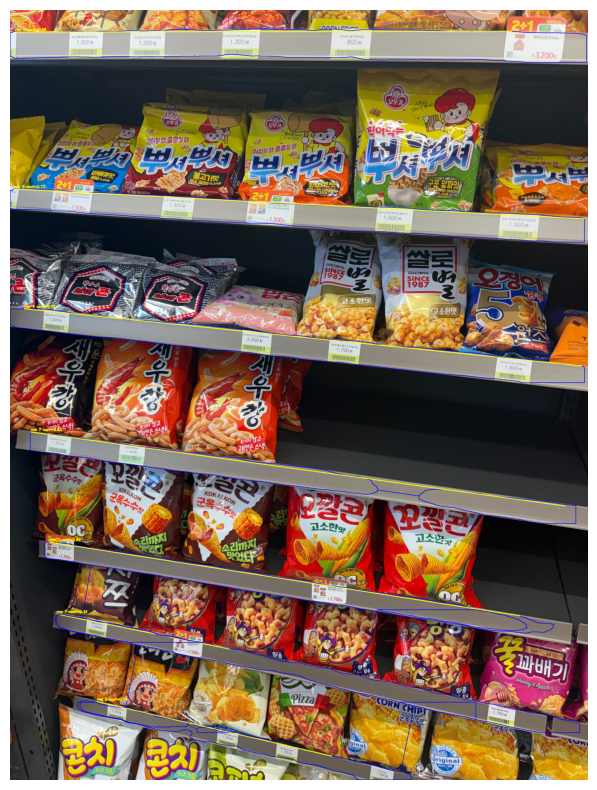

In [ ]:
# [셀 11] raw 후보 디버그용: 모델이 실제로 어떤 후보를 보는지 확인

SAMPLE_IDX = 0
sample_path = image_paths[SAMPLE_IDX]
print("디버그 이미지:", sample_path.name)

img = read_image_bgr(sample_path)
h, w = img.shape[:2]

result = model.predict(
    source=str(sample_path),
    imgsz=IMGSZ,
    conf=0.05,
    iou=IOU_THRES,
    retina_masks=True,
    verbose=False,
)[0]

debug_vis = img.copy()
raw_candidate_rows = []

if result.masks is None:
    print("예측된 mask 없음")
else:
    polys = result.masks.xy
    if result.boxes is not None and result.boxes.conf is not None:
        confs = result.boxes.conf.detach().cpu().numpy().tolist()
    else:
        confs = [1.0] * len(polys)

    print("raw mask 후보 개수:", len(polys))

    for idx, (poly, conf) in enumerate(zip(polys, confs), start=1):
        mask = polygon_to_mask(poly, h, w)
        line = extract_upper_line_from_mask(
            mask,
            conf=conf,
            min_width_ratio=0.03,
            min_area_ratio=0.00001,
            max_abs_angle=MAX_ABS_ANGLE,
            x_bin=X_BIN,
            smooth_window=SMOOTH_WINDOW,
        )

        pts = np.array(poly, dtype=np.int32)
        cv2.polylines(debug_vis, [pts], isClosed=True, color=(255, 0, 0), thickness=2)

        if line is not None:
            x1, y1 = int(line["x1"]), int(line["y1"])
            x2, y2 = int(line["x2"]), int(line["y2"])
            cv2.line(debug_vis, (x1, y1), (x2, y2), (0, 255, 255), 3)
            cv2.putText(
                debug_vis,
                f"raw {idx} conf={conf:.2f}",
                (max(5, x1), max(25, y1 - 6)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.6,
                (0, 255, 255),
                2,
                cv2.LINE_AA,
            )

            raw_candidate_rows.append({
                "idx": idx,
                "conf": round(float(conf), 4),
                "x1": line["x1"],
                "y1": line["y1"],
                "x2": line["x2"],
                "y2": line["y2"],
                "y_mid": round(line["y_mid"], 2),
                "width_ratio": round(line["width_ratio"], 4),
                "angle": round(line["angle"], 2),
            })

raw_df = pd.DataFrame(raw_candidate_rows)
if len(raw_df) > 0:
    display(raw_df.sort_values("y_mid"))
else:
    print("raw line 후보 없음")

plt.figure(figsize=(16, 10))
plt.imshow(cv2.cvtColor(debug_vis, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

In [ ]:
# [셀 12] 전체 test 이미지에 윗선 추출 적용 + 시각화/JSON/CSV 저장

LIMIT = None
# 일부만 돌리고 싶으면 예: LIMIT = 5
# 전체 돌릴 거면 LIMIT = None

target_paths = image_paths if LIMIT is None else image_paths[:LIMIT]
summary_rows = []

for idx, image_path in enumerate(target_paths, start=1):
    print(f"[{idx}/{len(target_paths)}] {image_path.name}")

    try:
        lines, result = predict_upper_lines_for_image(
            image_path,
            model,
            imgsz=IMGSZ,
            conf_thres=CONF_THRES,
            iou_thres=IOU_THRES,
            min_width_ratio=MIN_CANDIDATE_WIDTH_RATIO,
            min_area_ratio=MIN_AREA_RATIO,
        )

        img = read_image_bgr(image_path)
        h, w = img.shape[:2]

        vis_save_path = VIS_DIR / f"{image_path.stem}_upper_lines.jpg"
        json_save_path = JSON_DIR / f"{image_path.stem}_upper_lines.json"

        draw_upper_lines(image_path, lines, save_path=vis_save_path)
        json_lines = [line_to_jsonable(line) for line in lines]

        json_data = {
            "image_name": image_path.name,
            "image_path": str(image_path),
            "image_width": int(w),
            "image_height": int(h),
            "model_run_name": TARGET_RUN_NAME,
            "model_path": str(BEST_MODEL_PATH),
            "created_at": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
            "num_upper_lines": int(len(lines)),
            "params": {
                "imgsz": IMGSZ,
                "conf_thres": CONF_THRES,
                "iou_thres": IOU_THRES,
                "min_candidate_width_ratio": MIN_CANDIDATE_WIDTH_RATIO,
                "min_final_width_ratio": MIN_FINAL_WIDTH_RATIO,
                "min_area_ratio": MIN_AREA_RATIO,
                "max_abs_angle": MAX_ABS_ANGLE,
                "x_bin": X_BIN,
                "smooth_window": SMOOTH_WINDOW,
                "merge_y_thresh": MERGE_Y_THRESH,
                "merge_slope_thresh": MERGE_SLOPE_THRESH,
                "use_close_suppression": USE_CLOSE_SUPPRESSION,
                "min_vertical_gap": MIN_VERTICAL_GAP,
                "max_shelf_lines": MAX_SHELF_LINES,
                "extend_line_to_full_width": EXTEND_LINE_TO_FULL_WIDTH,
                "extend_margin_ratio": EXTEND_MARGIN_RATIO,
            },
            "lines": json_lines,
        }

        with open(json_save_path, "w", encoding="utf-8") as f:
            json.dump(json_data, f, ensure_ascii=False, indent=2)

        for line in json_lines:
            summary_rows.append({
                "image_name": image_path.name,
                "num_upper_lines": len(lines),
                "shelf_index": line["shelf_index"],
                "x1": line["x1"],
                "y1": line["y1"],
                "x2": line["x2"],
                "y2": line["y2"],
                "y_mid": line["y_mid"],
                "slope": line["slope"],
                "angle": line["angle"],
                "conf": line["conf"],
                "max_conf": line["max_conf"],
                "width_ratio": line["width_ratio"],
                "score": line["score"],
                "detected_x1": line["detected_x1"],
                "detected_y1": line["detected_y1"],
                "detected_x2": line["detected_x2"],
                "detected_y2": line["detected_y2"],
                "visual_path": str(vis_save_path),
                "json_path": str(json_save_path),
            })

        print("  윗선 개수:", len(lines))
        print("  저장:", vis_save_path)

    except Exception as e:
        print("[오류]", image_path.name, e)

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(CSV_PATH, index=False, encoding="utf-8-sig")

print("전체 완료")
print("CSV 저장:", CSV_PATH)
print("시각화 저장 폴더:", VIS_DIR)
print("JSON 저장 폴더:", JSON_DIR)

display(summary_df.head(20))

[1/13] IMG_8235.jpg
  윗선 개수: 6
  저장: /content/drive/MyDrive/먼작귀/shelf_detection/outputs/upper_line_postprocess_final_margin/visuals/IMG_8235_upper_lines.jpg
[2/13] PhotoshopExtension_Image_12.jpeg
  윗선 개수: 1
  저장: /content/drive/MyDrive/먼작귀/shelf_detection/outputs/upper_line_postprocess_final_margin/visuals/PhotoshopExtension_Image_12_upper_lines.jpg
[3/13] PhotoshopExtension_Image_21.jpeg
  윗선 개수: 4
  저장: /content/drive/MyDrive/먼작귀/shelf_detection/outputs/upper_line_postprocess_final_margin/visuals/PhotoshopExtension_Image_21_upper_lines.jpg
[4/13] PhotoshopExtension_Image_22.jpeg
  윗선 개수: 5
  저장: /content/drive/MyDrive/먼작귀/shelf_detection/outputs/upper_line_postprocess_final_margin/visuals/PhotoshopExtension_Image_22_upper_lines.jpg
[5/13] PhotoshopExtension_Image_26.jpeg
  윗선 개수: 4
  저장: /content/drive/MyDrive/먼작귀/shelf_detection/outputs/upper_line_postprocess_final_margin/visuals/PhotoshopExtension_Image_26_upper_lines.jpg
[6/13] PhotoshopExtension_Image_54.jpeg
  윗선 개수: 3
  저장: /c

,image_name,num_upper_lines,shelf_index,x1,y1,x2,y2,y_mid,slope,angle,conf,max_conf,width_ratio,score,detected_x1,detected_y1,detected_x2,detected_y2,visual_path,json_path
0,IMG_8235.jpg,6,1,0,936,3023,1094,1015.0,0.052333,2.995714,0.733479,0.733479,0.999669,0.922953,21,937,3003,1093,/content/drive/MyDrive/먼작귀/shelf_detection/out...,/content/drive/MyDrive/먼작귀/shelf_detection/out...
1,IMG_8235.jpg,6,2,0,1556,3023,1867,1711.5,0.102792,5.868913,0.751256,0.751256,0.999669,0.911028,75,1564,2991,1863,/content/drive/MyDrive/먼작귀/shelf_detection/out...,/content/drive/MyDrive/먼작귀/shelf_detection/out...
2,IMG_8235.jpg,6,3,0,2194,3023,2613,2403.5,0.138638,7.893042,0.629124,0.629124,0.999669,0.850733,108,2209,2904,2597,/content/drive/MyDrive/먼작귀/shelf_detection/out...,/content/drive/MyDrive/먼작귀/shelf_detection/out...
3,IMG_8235.jpg,6,4,0,2754,3023,3227,2990.5,0.156607,8.900631,0.816958,0.816958,0.999669,0.814358,208,2786,2668,3172,/content/drive/MyDrive/먼작귀/shelf_detection/out...,/content/drive/MyDrive/먼작귀/shelf_detection/out...
4,IMG_8235.jpg,6,5,0,3101,3023,3688,3394.5,0.194122,10.985732,0.000000,0.000000,0.999669,0.000000,88,3119,2788,3643,/content/drive/MyDrive/먼작귀/shelf_detection/out...,/content/drive/MyDrive/먼작귀/shelf_detection/out...
5,IMG_8235.jpg,6,6,0,3516,3023,4031,3773.5,0.231637,13.041795,0.786195,0.786195,0.999669,0.501608,453,3621,1683,3906,/content/drive/MyDrive/먼작귀/shelf_detection/out...,/content/drive/MyDrive/먼작귀/shelf_detection/out...
6,PhotoshopExtension_Image_12.jpeg,1,1,300,1409,2834,1779,1594.0,0.145848,8.297944,0.610402,0.610402,0.837963,0.661529,541,1445,2593,1744,/content/drive/MyDrive/먼작귀/shelf_detection/out...,/content/drive/MyDrive/먼작귀/shelf_detection/out...
7,PhotoshopExtension_Image_21.jpeg,4,1,0,42,299,41,41.5,-0.001445,-0.082774,0.571010,0.571010,0.996667,0.787753,35,42,293,41,/content/drive/MyDrive/먼작귀/shelf_detection/out...,/content/drive/MyDrive/먼작귀/shelf_detection/out...
8,PhotoshopExtension_Image_21.jpeg,4,2,0,94,299,93,93.5,-0.003426,-0.196269,0.617625,0.617625,0.996667,0.814406,29,93,293,93,/content/drive/MyDrive/먼작귀/shelf_detection/out...,/content/drive/MyDrive/먼작귀/shelf_detection/out...
9,PhotoshopExtension_Image_21.jpeg,4,3,0,144,299,143,143.5,-0.004685,-0.268427,0.480811,0.480811,0.996667,0.792703,30,144,299,143,/content/drive/MyDrive/먼작귀/shelf_detection/out...,/content/drive/MyDrive/먼작귀/shelf_detection/out...
